# Effect of Gradient Transition Layer on Reflection/Transmission

Compares R(θ), |r(δ)|, and ∠r(δ) for a **tanh-profile** dielectric transition
against the sharp-interface **Fresnel** limit.

**Profile:** εr(z) = (ε₁+ε₂)/2 + (ε₂−ε₁)/2 · tanh(z/δ),   z ∈ [−4δ, 4δ]

**Parameters:** ε₁ = 1, ε₂ = 4, λ₀ = 1, δ/λ₀ ∈ {0.01, 0.05, 0.1, 0.2, 0.5, 0.7, 1.0, 2.0}

**Methods:**
- R(θ) sweep: `sweep_ode` with vmap for parallel evaluation at each δ
- Complex r vs δ: `HelmholtzSolver1D.solve_ode()` at three fixed angles (θ=0°, 30°, θ_B)

**Figures:**
1. R(θ) colorbar plot — TE and TM panels, δ mapped to plasma colormap (log scale)
2. |r| vs δ — convergence to Fresnel (3 subplots, horizontal Fresnel lines)
3. ∠r vs δ — phase behaviour vs gradient width (3 subplots)

In [1]:
import sys, io, contextlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import jax
jax.config.update("jax_enable_x64", True)
try:
    jax.config.update('jax_platform_name', 'gpu')
    _ = jax.devices('gpu')
    print("Using GPU:", jax.devices('gpu'), flush=True)
except RuntimeError:
    jax.config.update('jax_platform_name', 'cpu')
    print("GPU not available, using CPU.", flush=True)

import jax.numpy as jnp

sys.path.insert(0, '/scratch/gpfs/MIKHAILOVA/zl8336/APC523/Final')
from main import HelmholtzSolver1D, sweep_ode, build_interp_arrays, make_kz

Using GPU: [CudaDevice(id=0), CudaDevice(id=1)]
Using GPU: [CudaDevice(id=0), CudaDevice(id=1)]
2
[CudaDevice(id=0), CudaDevice(id=1)]


In [2]:
# ── Physical parameters ────────────────────────────────────────────────────────
lambda0 = 1.0
k0      = 2.0 * np.pi / lambda0
eps1, eps2 = 1.0, 4.0

theta_B = np.degrees(np.arctan(np.sqrt(eps2 / eps1)))   # Brewster angle
print(f"Brewster angle  θ_B = {theta_B:.4f}°")

# ── Sweep parameters ──────────────────────────────────────────────────────────
DELTAS        = np.array([0.01, 0.05, 0.1, 0.2, 0.5, 0.7, 1.0, 2.0])
N_DELTA       = len(DELTAS)

THETAS_SWEEP  = np.linspace(0.0, 85.0, 80)   # for R vs θ colorbar
N_THETA       = len(THETAS_SWEEP)

THETAS_FIXED  = [0.0, 30.0, theta_B]         # for convergence & phase plots
theta_labels  = ['θ = 0°', 'θ = 30°', f'θ = θ_B ≈ {theta_B:.1f}°']

N_INTERP      = 10000   # interpolation grid points for ε(z)
N_TRANS_SWEEP = 500     # dt0 hint for sweep_ode; accuracy governed by PIDController

# ── Profile and Fresnel helpers ───────────────────────────────────────────────
def eps_tanh(z, delta):
    return 0.5*(eps1 + eps2) + 0.5*(eps2 - eps1)*np.tanh(z / delta)

def fresnel_r(theta_deg, pol):
    kx  = k0 * np.sqrt(eps1) * np.sin(np.deg2rad(theta_deg))
    kz1 = make_kz(eps1, float(np.real(kx)), k0)
    kz2 = make_kz(eps2, float(np.real(kx)), k0)
    if pol == 'S':
        return complex((kz1 - kz2) / (kz1 + kz2))
    else:
        return complex((eps2*kz1 - eps1*kz2) / (eps2*kz1 + eps1*kz2))

R_te_fresnel = np.array([abs(fresnel_r(th, 'S'))**2 for th in THETAS_SWEEP])
R_tm_fresnel = np.array([abs(fresnel_r(th, 'P'))**2 for th in THETAS_SWEEP])

print(f"Fresnel R_TE(0°) = {R_te_fresnel[0]:.5f},  R_TM(0°) = {R_tm_fresnel[0]:.5f}")
print(f"Fresnel |r_TM|(θ_B) = {abs(fresnel_r(theta_B,'P')):.2e}  (Brewster: → 0)")

Brewster angle  θ_B = 63.4349°
Fresnel R_TE(0°) = 0.11111,  R_TM(0°) = 0.11111
Fresnel |r_TM|(θ_B) = 0.00e+00  (Brewster: → 0)


In [ ]:
# ── Precompute k-vector arrays over θ sweep (shape N_THETA) ───────────────────
kx_vals  = np.array([k0 * np.sqrt(eps1) * np.sin(np.deg2rad(th)) for th in THETAS_SWEEP])
kz1_vals = np.array([complex(make_kz(eps1, float(kx), k0)) for kx in kx_vals])
kz2_vals = np.array([complex(make_kz(eps2, float(kx), k0)) for kx in kx_vals])

kx_jnp  = jnp.array(kx_vals,  dtype=jnp.float64)
kz1_jnp = jnp.array(kz1_vals, dtype=jnp.complex128)
kz2_jnp = jnp.array(kz2_vals, dtype=jnp.complex128)

# ── θ sweep via sweep_ode for each δ ──────────────────────────────────────────
R_te = np.zeros((N_DELTA, N_THETA))
R_tm = np.zeros((N_DELTA, N_THETA))

for i_d, delta in enumerate(DELTAS):
    z1_d, z2_d = -4.0 * delta, 4.0 * delta

    def _eps(z, _d=delta):
        return eps_tanh(z, _d)

    z_grid_d, eps_d, deps_d = build_interp_arrays(_eps, z1_d, z2_d, n=N_INTERP)

    eps_re_b  = jnp.tile(jnp.real(eps_d )[None, :], (N_THETA, 1))
    eps_im_b  = jnp.tile(jnp.imag(eps_d )[None, :], (N_THETA, 1))
    deps_re_b = jnp.tile(jnp.real(deps_d)[None, :], (N_THETA, 1))
    deps_im_b = jnp.tile(jnp.imag(deps_d)[None, :], (N_THETA, 1))

    R_te[i_d] = np.array(sweep_ode(
        kx_jnp, kz1_jnp, kz2_jnp,
        eps_re_b, eps_im_b, deps_re_b, deps_im_b,
        z_grid_d, float(k0), float(z1_d), float(z2_d), N_TRANS_SWEEP, 'S',
    ))
    R_tm[i_d] = np.array(sweep_ode(
        kx_jnp, kz1_jnp, kz2_jnp,
        eps_re_b, eps_im_b, deps_re_b, deps_im_b,
        z_grid_d, float(k0), float(z1_d), float(z2_d), N_TRANS_SWEEP, 'P',
    ))
    print(f"delta = {delta:.2f}λ₀  R_TE(0°) = {R_te[i_d, 0]:.5f}  "
          f"R_TM(0°) = {R_tm[i_d, 0]:.5f}", flush=True)

print("\nθ sweep complete.")

delta = 0.01λ₀  R_TE(0°) = 0.10828  R_TM(0°) = 0.10798
delta = 0.05λ₀  R_TE(0°) = 0.06080  R_TM(0°) = 0.06096
delta = 0.10λ₀  R_TE(0°) = 0.01435  R_TM(0°) = 0.01436
delta = 0.20λ₀  R_TE(0°) = 0.00035  R_TM(0°) = 0.00037
delta = 0.50λ₀  R_TE(0°) = 0.00000  R_TM(0°) = 0.00000
delta = 0.70λ₀  R_TE(0°) = 0.00000  R_TM(0°) = 0.00000
delta = 1.00λ₀  R_TE(0°) = 0.00000  R_TM(0°) = 0.00000
delta = 2.00λ₀  R_TE(0°) = 0.00000  R_TM(0°) = 0.00000

θ sweep complete.


: 

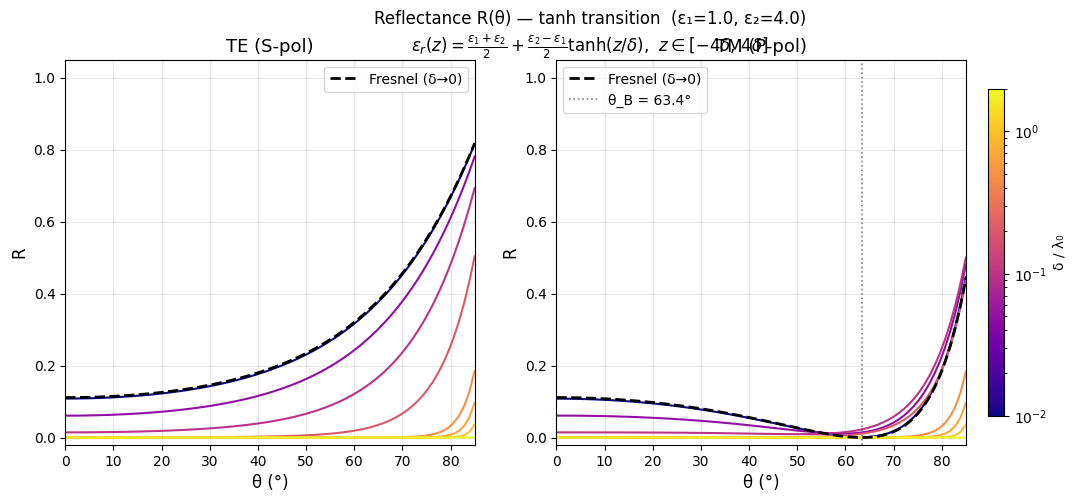

In [ ]:
# ── Figure 1: R(θ) colorbar plot — TE and TM panels ──────────────────────────
cmap = plt.cm.plasma
norm = mcolors.LogNorm(vmin=DELTAS[0], vmax=DELTAS[-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i_d, delta in enumerate(DELTAS):
    c = cmap(norm(delta))
    axes[0].plot(THETAS_SWEEP, R_te[i_d], color=c, lw=1.5)
    axes[1].plot(THETAS_SWEEP, R_tm[i_d], color=c, lw=1.5)

# Fresnel (sharp interface)
axes[0].plot(THETAS_SWEEP, R_te_fresnel, 'k--', lw=2.0, label='Fresnel (δ→0)')
axes[1].plot(THETAS_SWEEP, R_tm_fresnel, 'k--', lw=2.0, label='Fresnel (δ→0)')
axes[1].axvline(theta_B, color='gray', ls=':', lw=1.2, label=f'θ_B = {theta_B:.1f}°')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes.ravel().tolist(), label='δ / λ₀', shrink=0.85, pad=0.02)

for ax, pol_name in zip(axes, ['TE (S-pol)', 'TM (P-pol)']):
    ax.set_xlabel('θ (°)', fontsize=12)
    ax.set_ylabel('R', fontsize=12)
    ax.set_title(pol_name, fontsize=13)
    ax.set_xlim(0, 85)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Reflectance R(θ) — tanh transition  (ε₁={eps1}, ε₂={eps2})\n'
    r'$\varepsilon_r(z)=\frac{\varepsilon_1+\varepsilon_2}{2}'
    r'+\frac{\varepsilon_2-\varepsilon_1}{2}\tanh(z/\delta)$,'
    r'  $z\in[-4\delta,\,4\delta]$',
    fontsize=12)

plt.tight_layout()
plt.savefig('gradient_R_vs_theta.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── Compute complex r vs δ at three fixed angles ──────────────────────────────
# Uses HelmholtzSolver1D.solve_ode() (auto resolution, complex r returned)
r_te = np.zeros((len(THETAS_FIXED), N_DELTA), dtype=complex)
r_tm = np.zeros((len(THETAS_FIXED), N_DELTA), dtype=complex)

for i_t, theta in enumerate(THETAS_FIXED):
    for i_d, delta in enumerate(DELTAS):
        z1_d, z2_d = -4.0 * delta, 4.0 * delta

        def _eps(z, _d=delta):
            return eps_tanh(z, _d)

        with contextlib.redirect_stdout(io.StringIO()):
            sv_te = HelmholtzSolver1D(_eps, z1_d, z2_d,
                                      theta_deg=float(theta), pol='S', lambda0=lambda0)
            sv_tm = HelmholtzSolver1D(_eps, z1_d, z2_d,
                                      theta_deg=float(theta), pol='P', lambda0=lambda0)
            r_te[i_t, i_d] = sv_te.solve_ode()['r']
            r_tm[i_t, i_d] = sv_tm.solve_ode()['r']

    print(f"θ = {theta:.2f}° done.", flush=True)

print("\nDelta sweep complete.")

θ = 0.00° done.
θ = 30.00° done.
θ = 63.43° done.

Delta sweep complete.


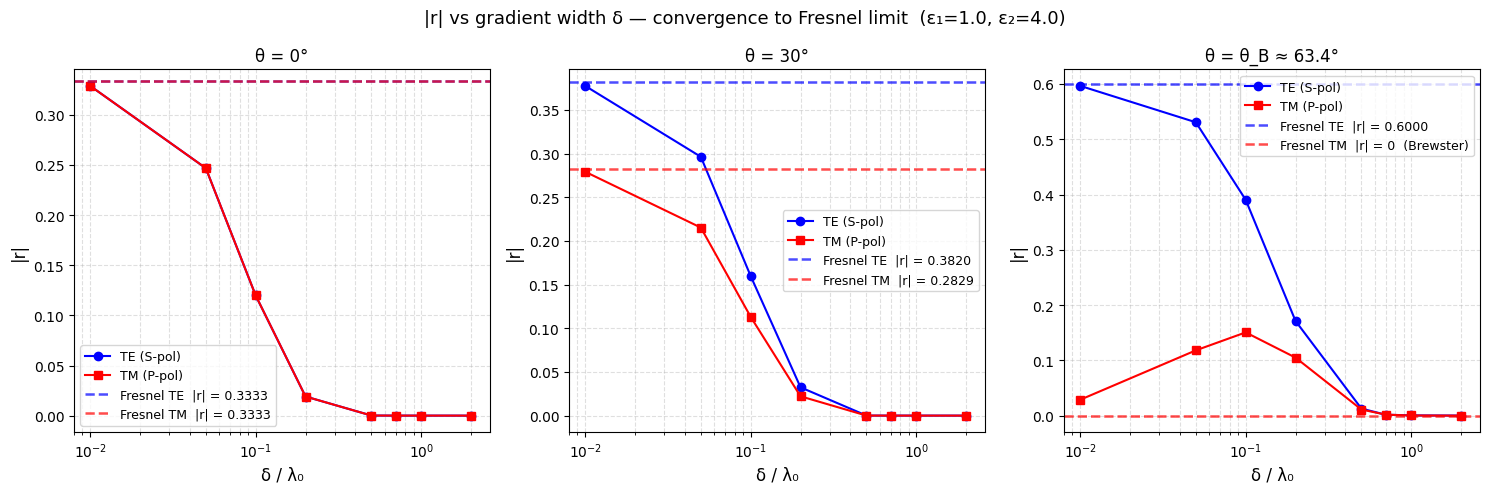

In [6]:
# ── Figure 2: |r| vs δ — convergence to Fresnel ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i_t, (theta, label) in enumerate(zip(THETAS_FIXED, theta_labels)):
    ax = axes[i_t]

    ax.semilogx(DELTAS, np.abs(r_te[i_t]), 'bo-', ms=6, lw=1.5, label='TE (S-pol)')
    ax.semilogx(DELTAS, np.abs(r_tm[i_t]), 'rs-', ms=6, lw=1.5, label='TM (P-pol)')

    r_te_f = fresnel_r(theta, 'S')
    r_tm_f = fresnel_r(theta, 'P')

    ax.axhline(abs(r_te_f), color='b', ls='--', lw=1.8, alpha=0.7,
               label=f'Fresnel TE  |r| = {abs(r_te_f):.4f}')
    if abs(r_tm_f) > 1e-6:
        ax.axhline(abs(r_tm_f), color='r', ls='--', lw=1.8, alpha=0.7,
                   label=f'Fresnel TM  |r| = {abs(r_tm_f):.4f}')
    else:
        ax.axhline(0.0, color='r', ls='--', lw=1.8, alpha=0.7,
                   label='Fresnel TM  |r| = 0  (Brewster)')

    ax.set_xlabel('δ / λ₀', fontsize=12)
    ax.set_ylabel('|r|', fontsize=12)
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, which='both', ls='--', alpha=0.4)
    ax.set_xlim(DELTAS[0]*0.8, DELTAS[-1]*1.3)

fig.suptitle(
    f'|r| vs gradient width δ — convergence to Fresnel limit  (ε₁={eps1}, ε₂={eps2})',
    fontsize=13)
plt.tight_layout()
plt.savefig('gradient_r_vs_delta.png', dpi=150, bbox_inches='tight')
plt.show()

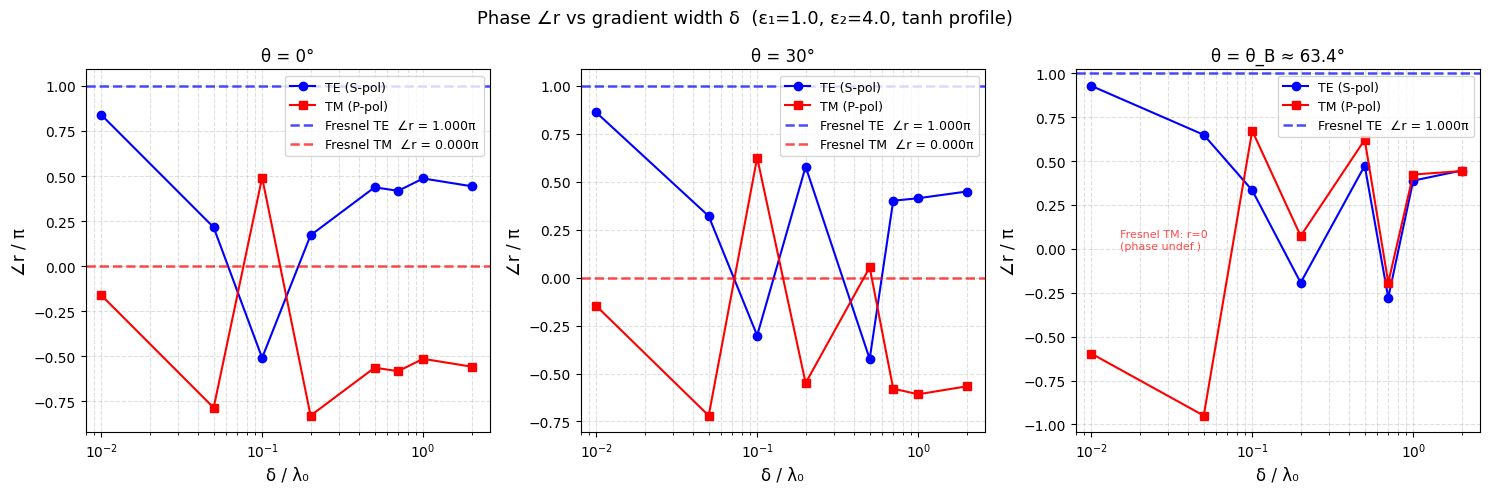

In [7]:
# ── Figure 3: ∠r vs δ — phase behaviour ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i_t, (theta, label) in enumerate(zip(THETAS_FIXED, theta_labels)):
    ax = axes[i_t]

    ax.semilogx(DELTAS, np.angle(r_te[i_t]) / np.pi, 'bo-', ms=6, lw=1.5, label='TE (S-pol)')
    ax.semilogx(DELTAS, np.angle(r_tm[i_t]) / np.pi, 'rs-', ms=6, lw=1.5, label='TM (P-pol)')

    r_te_f = fresnel_r(theta, 'S')
    r_tm_f = fresnel_r(theta, 'P')

    if abs(r_te_f) > 1e-6:
        ax.axhline(np.angle(r_te_f) / np.pi, color='b', ls='--', lw=1.8, alpha=0.7,
                   label=f'Fresnel TE  ∠r = {np.angle(r_te_f)/np.pi:.3f}π')
    if abs(r_tm_f) > 1e-6:
        ax.axhline(np.angle(r_tm_f) / np.pi, color='r', ls='--', lw=1.8, alpha=0.7,
                   label=f'Fresnel TM  ∠r = {np.angle(r_tm_f)/np.pi:.3f}π')
    else:
        ax.annotate('Fresnel TM: r=0\n(phase undef.)', xy=(DELTAS[0]*1.5, 0),
                    fontsize=8, color='r', alpha=0.7)

    ax.set_xlabel('δ / λ₀', fontsize=12)
    ax.set_ylabel('∠r / π', fontsize=12)
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, which='both', ls='--', alpha=0.4)
    ax.set_xlim(DELTAS[0]*0.8, DELTAS[-1]*1.3)

fig.suptitle(
    f'Phase ∠r vs gradient width δ  (ε₁={eps1}, ε₂={eps2}, tanh profile)',
    fontsize=13)
plt.tight_layout()
plt.savefig('gradient_phase_vs_delta.png', dpi=150, bbox_inches='tight')
plt.show()